In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [10]:

# 1) Carica il file .pt
path = "reprs_paper_1400_16_b0000_layer26.pt"
save_obj = torch.load(path, map_location="cpu")

input_ids = save_obj["input_ids_last"]
emb = save_obj["embeddings_last"]

# 2) Normalizza le shape in (T,) e (T, H)
# input_ids può essere [T] oppure [1, T]
if isinstance(input_ids, torch.Tensor):
    input_ids = input_ids.detach().cpu()
else:
    input_ids = torch.tensor(input_ids)

if input_ids.ndim == 2 and input_ids.shape[0] == 1:
    input_ids = input_ids[0]
elif input_ids.ndim != 1:
    raise ValueError(f"input_ids_last ha shape inattesa: {tuple(input_ids.shape)}")

# embeddings può essere [T, H] oppure [1, T, H]
if isinstance(emb, torch.Tensor):
    emb = emb.detach().cpu()
else:
    emb = torch.tensor(emb)

if emb.ndim == 3 and emb.shape[0] == 1:
    emb = emb[0]
elif emb.ndim != 2:
    raise ValueError(f"embeddings_last ha shape inattesa: {tuple(emb.shape)}")


In [11]:

T = min(len(input_ids), emb.shape[0])
input_ids = input_ids[:T]
emb = emb[:T]

X = emb.numpy()  # (T, H)
token_ids = input_ids.numpy()  # (T,)

print("Shapes:", X.shape, token_ids.shape)
print("Token ids unici:", np.unique(token_ids).shape[0])


Shapes: (50, 4096) (50,)
Token ids unici: 14


In [12]:

# 3) PCA a 2 componenti
pca = PCA(n_components=2, random_state=0)
X2 = pca.fit_transform(X)  # (T, 2)
print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.18588281 0.13310536]


In [13]:
id_to_token = {
    128000: '<|begin_of_text|>',
    23182: 'apple',
    12224: 'Ġbird',
    1841: 'Ġcar',
    19151: 'Ġegg',
    3838: 'Ġhouse',
    14403: 'Ġmilk',
    11277: 'Ġplane',
    43516: 'Ġopera',
    3830: 'Ġbox',
    9462: 'Ġsand',
    7160: 'Ġsun',
    70368: 'Ġmango',
    7091: 'Ġrock',
    7033: 'Ġmath',
    2082: 'Ġcode',
    4641: 'Ġphone',
}


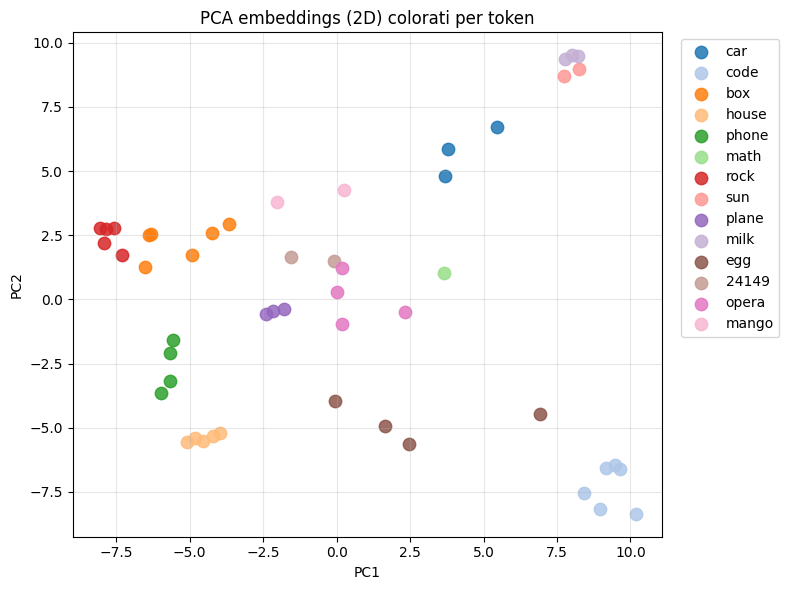

In [14]:
# --- Plot ---
unique_ids = np.unique(token_ids)
cmap = plt.get_cmap("tab20")

plt.figure(figsize=(8, 6))

for i, tid in enumerate(unique_ids):
    mask = token_ids == tid
    
    # prendi il nome del token dal dizionario
    token_label = id_to_token.get(int(tid), str(tid)).replace("Ġ", "")
    
    plt.scatter(
        X2[mask, 0],
        X2[mask, 1],
        s=80,
        alpha=0.85,
        color=cmap(i % cmap.N),
        label=token_label
    )

plt.title("PCA embeddings (2D) colorati per token")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()